In [408]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
import importlib
import Funciones_Copa_Europa_Euroliga # si no lo hago asi no me actualiza las funciones
importlib.reload(Funciones_Copa_Europa_Euroliga)

<module 'Funciones_Copa_Europa_Euroliga' from 'e:\\10 - curso IRONHACK_Analisis_de_datos\\git-practice\\Proyectos\\3-Proyecto-Fin-Baloncesto-Europa\\Proyecto_Euroleague\\Funciones_Copa_Europa_Euroliga.py'>

In [409]:


Funciones_Copa_Europa_Euroliga.ver_lista_funciones()



Funciones disponibles en utilidades:

 - activar_vista_larga
 - añadir_paises_df
 - cambiar_nombres_columna
 - comprobar_tablas
 - diccionario_ganadores
 - eliminar_duplicados
 - equipos_campeones
 - generar_todas
 - grafico_timeline
 - guardar
 - limpiar_texto
 - no_es_navbox
 - opciones__visualizar_dataframe
 - opciones_comprobar_tablas
 - opciones_ver_etiquetas
 - restaurar_vista
 - resumen_ganadores
 - sacar_valores_columna
 - tiene_cabeceras
 - tiene_columnas
 - tiene_filas
 - tiene_texto_util
 - traducir_paises_ingles
 - ver_etiquetas
 - ver_lista_funciones
 - winner_champions


['activar_vista_larga',
 'añadir_paises_df',
 'cambiar_nombres_columna',
 'comprobar_tablas',
 'diccionario_ganadores',
 'eliminar_duplicados',
 'equipos_campeones',
 'generar_todas',
 'grafico_timeline',
 'guardar',
 'limpiar_texto',
 'no_es_navbox',
 'opciones__visualizar_dataframe',
 'opciones_comprobar_tablas',
 'opciones_ver_etiquetas',
 'restaurar_vista',
 'resumen_ganadores',
 'sacar_valores_columna',
 'tiene_cabeceras',
 'tiene_columnas',
 'tiene_filas',
 'tiene_texto_util',
 'traducir_paises_ingles',
 'ver_etiquetas',
 'ver_lista_funciones',
 'winner_champions']

In [410]:
Funciones_Copa_Europa_Euroliga.activar_vista_larga()

In [411]:
df_trabajo = pd.read_csv('Copa_Europa_Euroleague.csv')
df_trabajo.head(1000)

,year_win,team,statenme,stateabb,styear,endyear
0,1958,A. S. K. Riga,Soviet Union,URS,1952,1988
1,1959,A. S. K. Riga,Soviet Union,URS,1952,1988
2,1960,P. B. K. CSKA,Soviet Union,URS,1952,1988
3,1961,B. C. Dinamo Tbilisi,Soviet Union,URS,1952,1988
4,1962,P. B. K. CSKA,Soviet Union,URS,1952,1988
5,1963,Real Madrid Baloncesto,Spain,SPN,1816,2024
6,1964,Real Madrid Baloncesto,Spain,SPN,1816,2024
7,1965,P. O. Milano,Italy,ITA,1816,2024
8,1966,Real Madrid Baloncesto,Spain,SPN,1816,2024
9,1967,Real Madrid Baloncesto,Spain,SPN,1816,2024


Voy a normalizar algunos nombres que son el mismo clun

In [412]:
normalizacion = {
    "Real Madrid": "Real Madrid",
    "Real Madrid CF": "Real Madrid",
    "CSKA": "CSKA Moscow",
    "CSKA Moscú": "CSKA Moscow",
    "P. B. K. CSKA" : "CSKA Moscow",
    "Maccabi": "Maccabi Tel Aviv",
    "Maccabi Elite": "Maccabi Tel Aviv",
    "Olimpia Milano": "Milano",
    "Olimpia Milan": "Milano",
    "Cibona Zagreb": "Cibona",
    "Jugoplastika": "Split",
    "Pop 84": "Split",
    "KK Split": "Split",
    "Panathinaikos B. C." : "Panathinaikos"

}

df_trabajo["team"] = df_trabajo["team"].replace(normalizacion)


In [413]:
lista_paises_campeones = Funciones_Copa_Europa_Euroliga.sacar_valores_columna(df_trabajo,'statenme')
lista_paises_campeones


['Soviet Union',
 'Spain',
 'Italy',
 'Israel',
 'Yugoslavia',
 'Serbia and Montenegro',
 'France',
 'Greece',
 'Lithuania',
 'Russia',
 'Turkey']

In [414]:
lista_equipos_campeones = Funciones_Copa_Europa_Euroliga.equipos_campeones(df_trabajo)
lista_equipos_campeones


,team,titulos
18,Panathinaikos,14
19,Real Madrid Baloncesto,11
4,CSKA Moscow,8
13,Maccabi Tel Aviv B. C.,6
10,K. K. Split,6
14,Olympiakos B. C.,6
17,Pallacanestro Varese,5
12,KK Cibona,4
15,P. O. Milano,3
6,F. C. Barcelona,2


In [415]:
diccionario_ganadores = Funciones_Copa_Europa_Euroliga.diccionario_ganadores(df_trabajo,'statenme')
for pais, veces in diccionario_ganadores.items():
    print(f"{pais}: {veces} títulos")

France: 2 títulos
Greece: 20 títulos
Israel: 6 títulos
Italy: 13 títulos
Lithuania: 2 títulos
Russia: 4 títulos
Serbia and Montenegro: 1 títulos
Soviet Union: 7 títulos
Spain: 14 títulos
Turkey: 4 títulos
Yugoslavia: 12 títulos


---

Filtrar fechas ANTES de la disolución (27 de abril de 1992) y DESPUES

In [416]:
sucesores_Yugoslavia = [
    "Bosnia and Herzegovina",
    "Croatia",
    "Kosovo",
    'Serbia and Montenegro', # estuvieron juntos hasta 2024
    "Serbia",
    "Montenegro",
    "North Macedonia",
    "Slovenia"
]


---

In [417]:
sucesores_Soviet_Union = [
    "Armenia",
    "Azerbaijan",
    "Belarus",
    "Estonia",
    "Georgia",
    "Kazakhstan",
    "Kyrgyzstan",
    "Latvia",
    "Lithuania",
    "Moldova",
    "Tajikistan",
    "Turkmenistan",
    "Ukraine",
    "Uzbekistan"
]



# GRAFICOS Y ESTADISTICAS

## TITULOS POR PAIS DE COPAS EUROPA + EUROLIGAS EN TOTAL

In [418]:
## Agrupar y ordenar de mayor a menor numero de titulo
titulos_paises = df_trabajo.groupby("statenme").size().reset_index(name="titulos")
titulos_paises = titulos_paises.sort_values("titulos", ascending=False)

C:\Users\ernes\AppData\Local\Temp\ipykernel_8000\2332739491.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


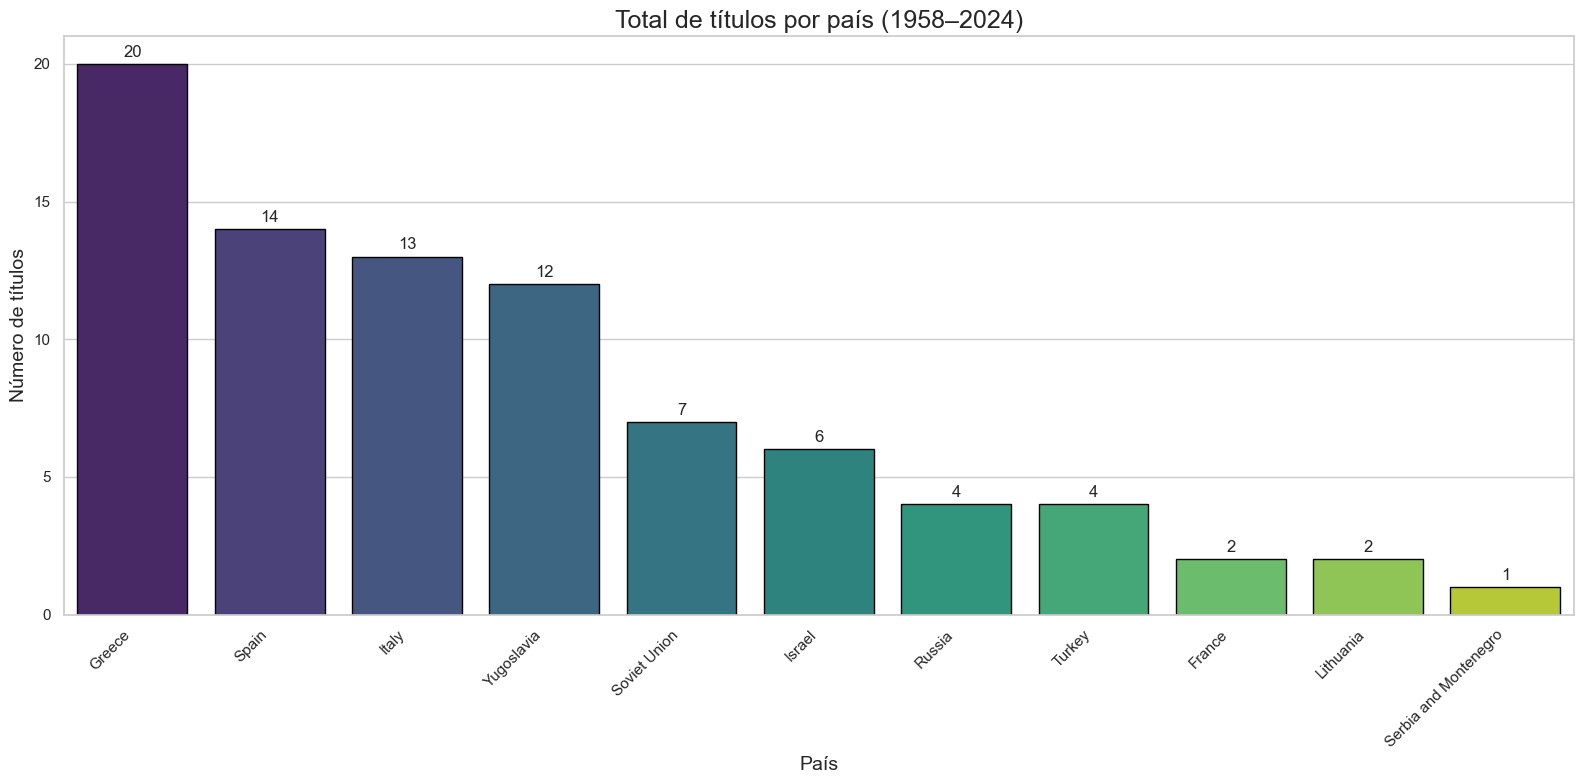

In [419]:

# 2) Gráfica de barras

plt.figure(figsize=(16,8))
ax = sns.barplot(
    data=titulos_paises,
    x="statenme",
    y="titulos",
    palette="viridis",
    edgecolor="black"
)

plt.title("Total de títulos por país (1958–2024)", fontsize=18)
plt.xlabel("País", fontsize=14)
plt.ylabel("Número de títulos", fontsize=14)

# Quitar floats del eje Y
plt.gca().yaxis.get_major_locator().set_params(integer=True)

plt.xticks(rotation=45, ha="right")


# 3) Añadir números encima de cada barra
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.tight_layout()
plt.savefig("Total de títulos por país (1958–2024)", dpi=300, bbox_inches="tight")
plt.show()


In [420]:
## Titulos por pais antes, despues de la division de la URSS-Yugosalvia y cambio a la Euroliga

In [421]:
## Definir los periodos
df_copa_hasta_1992 = df_trabajo[df_trabajo["year_win"] < 1992]
df_copa_desde_separacion = df_trabajo[(df_trabajo["year_win"] >= 1992) & (df_trabajo["year_win"] <= 2001)]
df_euroleague = df_trabajo[df_trabajo["year_win"] > 2001]

In [422]:
#  Agrupar por país
g1 = df_copa_hasta_1992.groupby("statenme").size().reset_index(name="Copa Europa hasta 1992")
g2 = df_copa_desde_separacion.groupby("statenme").size().reset_index(name="Copa Europa desde separación URSS-Yugoslavia")
g3 = df_euroleague.groupby("statenme").size().reset_index(name="Euroleague")

In [423]:
# 3) Unir todo en un solo DataFrame

comparativa = g1.merge(g2, on="statenme", how="outer") \
                .merge(g3, on="statenme", how="outer") \
                .fillna(0)

# Ordenar por total
comparativa["total"] = (
    comparativa["Copa Europa hasta 1992"] +
    comparativa["Copa Europa desde separación URSS-Yugoslavia"] +
    comparativa["Euroleague"]
)

comparativa = comparativa.sort_values("total", ascending=False)

<Figure size 1800x800 with 0 Axes>

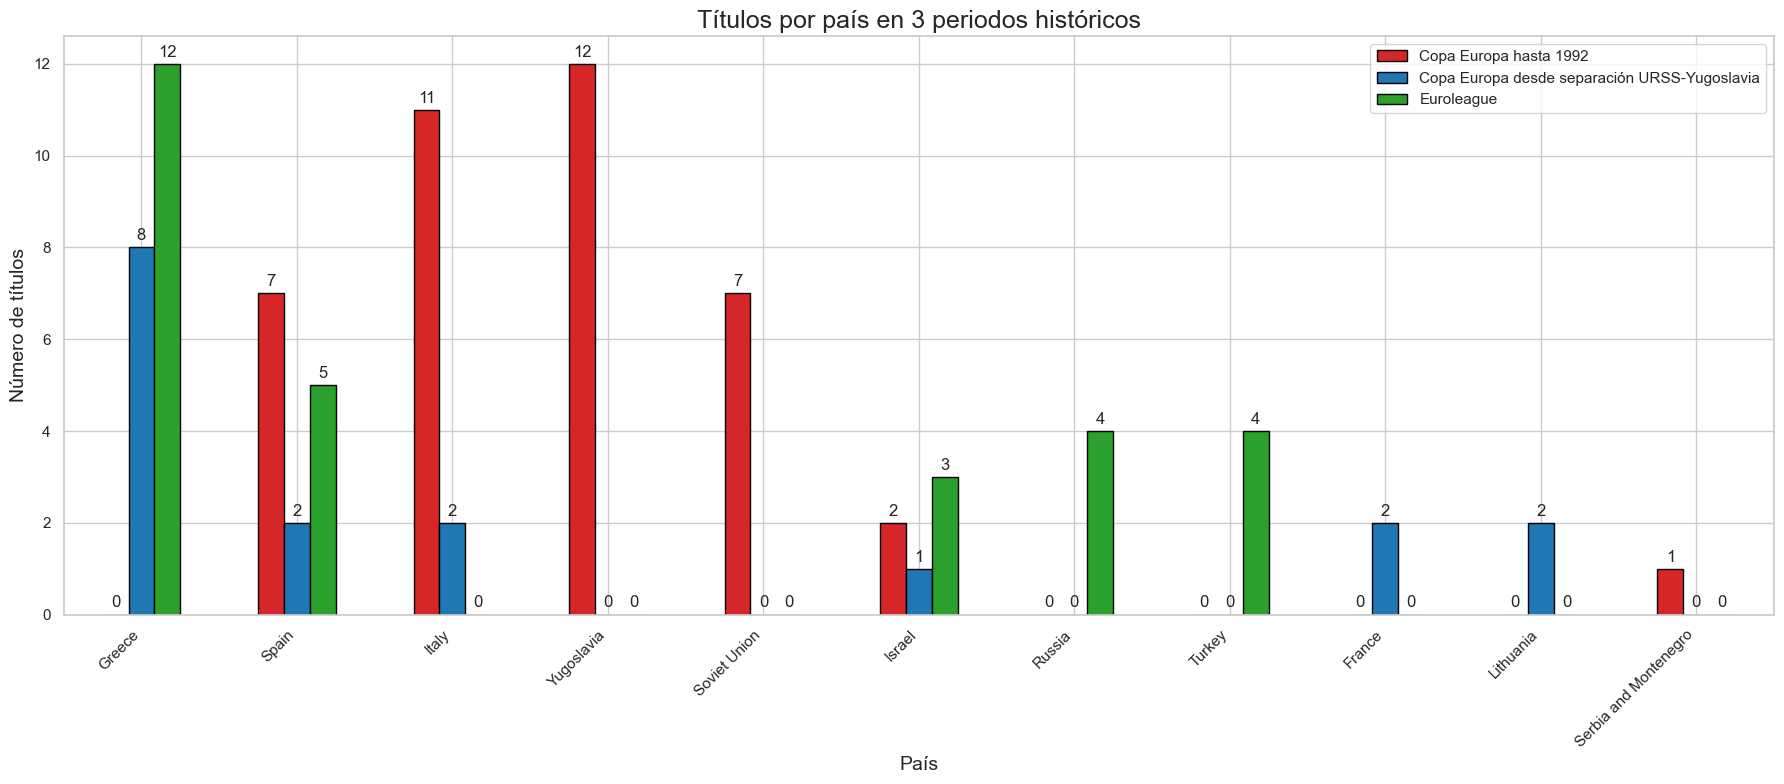

In [424]:

# 4) Gráfica de barras múltiples

plt.figure(figsize=(18,8))
ax = comparativa.set_index("statenme")[[
    "Copa Europa hasta 1992",
    "Copa Europa desde separación URSS-Yugoslavia",
    "Euroleague"
]].plot(
    kind="bar",
    figsize=(18,8),
    color=["#d62728", "#1f77b4", "#2ca02c"],
    edgecolor="black"
)

plt.title("Títulos por país en 3 periodos históricos", fontsize=18)
plt.xlabel("País", fontsize=14)
plt.ylabel("Número de títulos", fontsize=14)

#  Quitar floats del eje Y
plt.gca().yaxis.get_major_locator().set_params(integer=True)

plt.xticks(rotation=45, ha="right")
plt.legend([
    "Copa Europa hasta 1992",
    "Copa Europa desde separación URSS-Yugoslavia",
    "Euroleague"
])


# Añadir números encima de cada barra


for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.tight_layout()
plt.savefig("Títulos por país en 3 periodos históricos", dpi=300, bbox_inches="tight")
plt.show()


## Equipos con mas titulos

<Figure size 2000x1000 with 0 Axes>

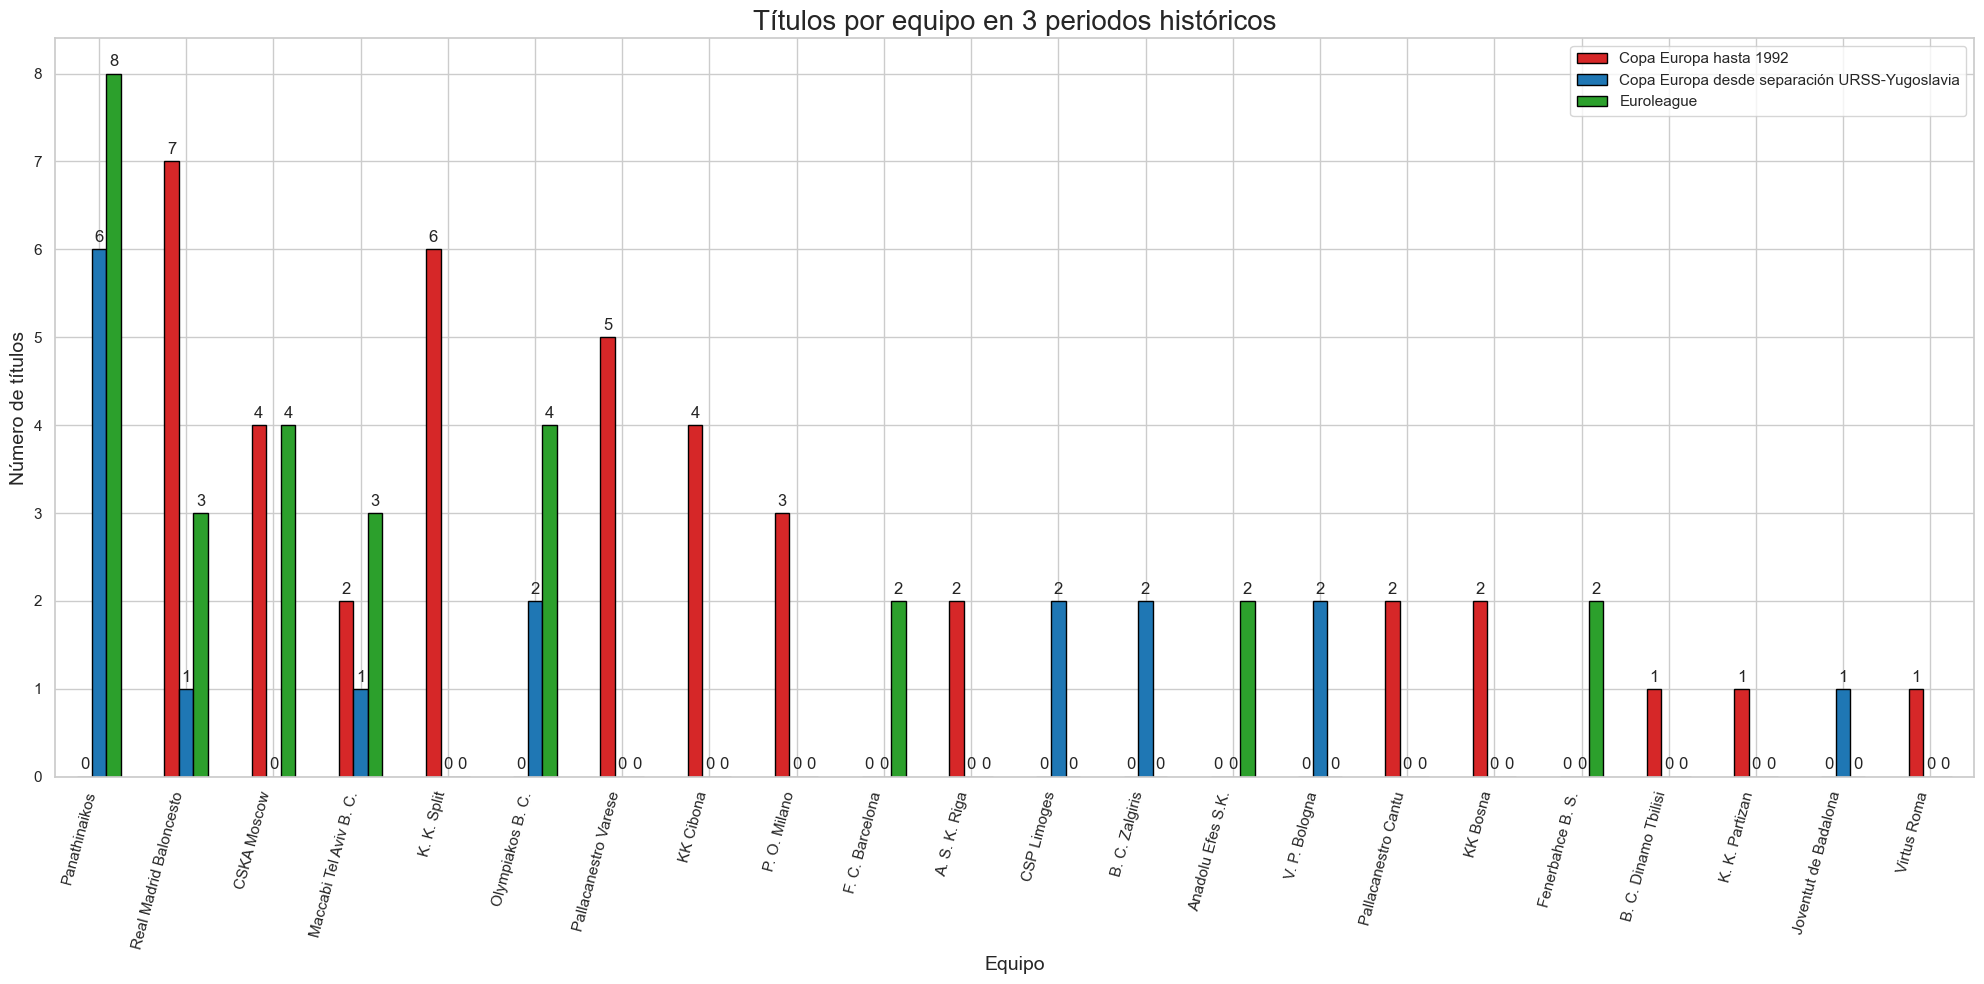

In [425]:



# 1) Definir los 3 periodos


df_copa_hasta_1992 = df_trabajo[df_trabajo["year_win"] < 1992]
df_copa_desde_separacion = df_trabajo[(df_trabajo["year_win"] >= 1992) & (df_trabajo["year_win"] <= 2001)]
df_euroleague = df_trabajo[df_trabajo["year_win"] > 2001]


# 2) Agrupar por equipo


g1 = df_copa_hasta_1992.groupby("team").size().reset_index(name="Copa Europa hasta 1992")
g2 = df_copa_desde_separacion.groupby("team").size().reset_index(name="Copa Europa desde separación URSS-Yugoslavia")
g3 = df_euroleague.groupby("team").size().reset_index(name="Euroleague")


# 3) Unir todo en un solo DataFrame


comparativa = g1.merge(g2, on="team", how="outer") \
                .merge(g3, on="team", how="outer") \
                .fillna(0)

# Ordenar por total
comparativa["total"] = (
    comparativa["Copa Europa hasta 1992"] +
    comparativa["Copa Europa desde separación URSS-Yugoslavia"] +
    comparativa["Euroleague"]
)

comparativa = comparativa.sort_values("total", ascending=False)


# 4) Gráfica de barras múltiples


plt.figure(figsize=(20,10))
ax = comparativa.set_index("team")[[
    "Copa Europa hasta 1992",
    "Copa Europa desde separación URSS-Yugoslavia",
    "Euroleague"
]].plot(
    kind="bar",
    figsize=(20,10),
    color=["#d62728", "#1f77b4", "#2ca02c"],
    edgecolor="black"
)

plt.title("Títulos por equipo en 3 periodos históricos", fontsize=20)
plt.xlabel("Equipo", fontsize=14)
plt.ylabel("Número de títulos", fontsize=14)

# 🔥 Quitar floats del eje Y
plt.gca().yaxis.get_major_locator().set_params(integer=True)

plt.xticks(rotation=75, ha="right")
plt.legend([
    "Copa Europa hasta 1992",
    "Copa Europa desde separación URSS-Yugoslavia",
    "Euroleague"
])


# 5) Añadir números encima de cada barra


for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.tight_layout()
plt.savefig("Títulos por equipo en 3 periodos históricos", dpi=300, bbox_inches="tight")
plt.show()


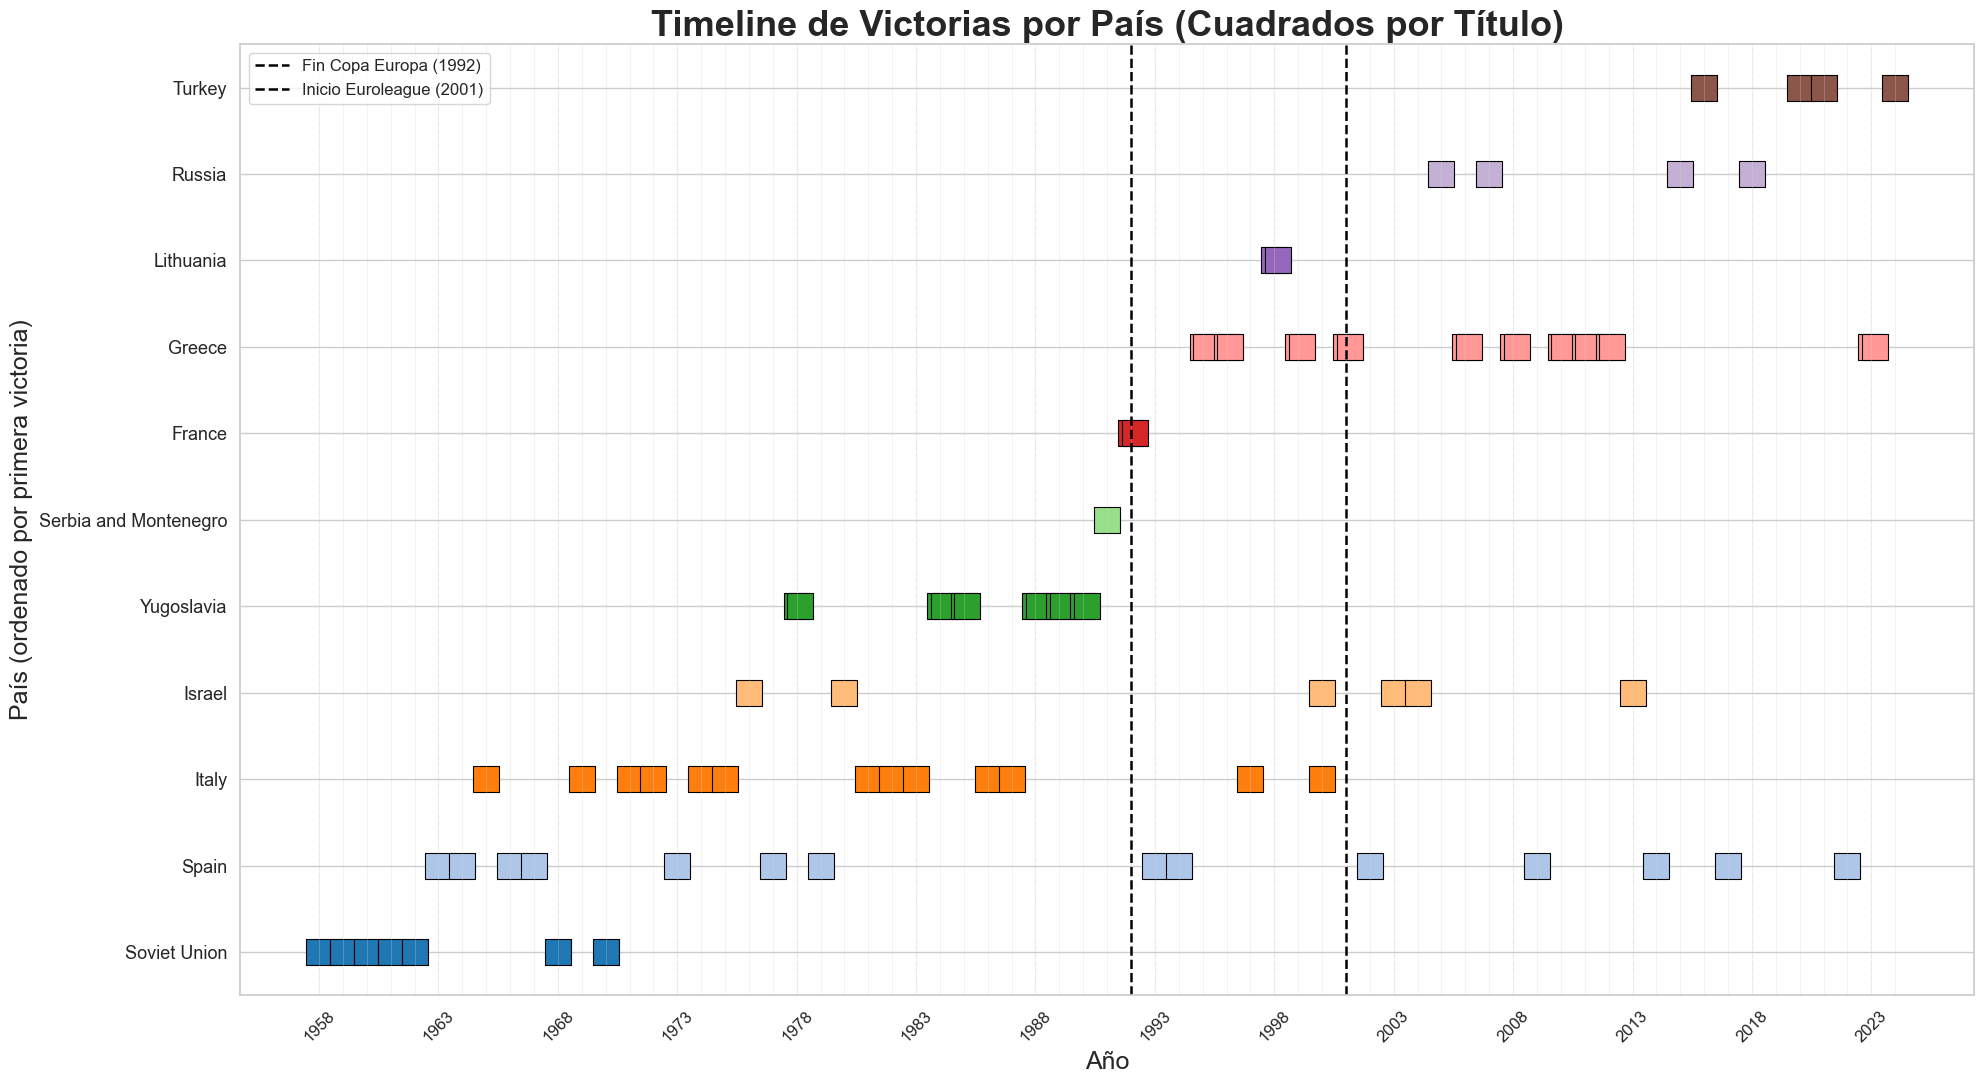

In [426]:
import matplotlib.pyplot as plt
import pandas as pd

# ============================
# 1) Preparar datos
# ============================

df = df_trabajo.copy()

# Agrupar por país y año
victorias = df.groupby(["statenme", "year_win"]).size().reset_index(name="wins")

# Ordenar países por PRIMER año de victoria
orden_paises = (
    victorias.groupby("statenme")["year_win"]
    .min()
    .sort_values()
    .index
)

# ============================
# 2) Crear gráfico con CUADRADOS
# ============================

plt.figure(figsize=(20, 11))

colores = plt.cm.tab20.colors

for i, pais in enumerate(orden_paises):
    subset = victorias[victorias["statenme"] == pais]
    
    for _, row in subset.iterrows():
        año = row["year_win"]
        wins = row["wins"]  # normalmente 1
        
        for k in range(wins):
            plt.scatter(
                año + k*0.15,
                pais,
                s=350,
                marker="s",
                color=colores[i % len(colores)],
                edgecolor="black",
                linewidth=0.8
            )

# ============================
# 3) Líneas verticales finas (cada año)
# ============================

for year in range(df["year_win"].min(), df["year_win"].max()+1):
    plt.axvline(year, color="lightgray", linestyle="-", linewidth=0.4, alpha=0.5)

# ============================
# 4) Líneas verticales de periodos (gruesas)
# ============================

plt.axvline(1992, color="black", linestyle="--", linewidth=1.8, label="Fin Copa Europa (1992)")
plt.axvline(2001, color="black", linestyle="--", linewidth=1.8, label="Inicio Euroleague (2001)")

# ============================
# 5) Decoración estilo presentación
# ============================

plt.title("Timeline de Victorias por País (Cuadrados por Título)", fontsize=26, fontweight="bold")
plt.xlabel("Año", fontsize=18)
plt.ylabel("País (ordenado por primera victoria)", fontsize=18)

plt.xticks(range(df["year_win"].min(), df["year_win"].max()+1, 5), rotation=45, fontsize=12)
plt.yticks(fontsize=13)

plt.grid(axis="x", linestyle="--", alpha=0.25)

# ============================
# 6) Leyenda colocada donde no moleste
# ============================

plt.legend(loc="upper left", fontsize=12, frameon=True)

plt.tight_layout()
plt.savefig("Timeline de Victorias por País", dpi=300, bbox_inches="tight")
plt.show()


In [427]:
# Guardar graficas